# Depth-Averaged Submarine Melt Deviation (PDS) Histograms

This notebook visualizes the distribution of depth-averaged percentage deviation in submarine melt (PDS) between near-glacier and fjord-mouth profiles. Positive values are instances where the depth-averaged melt rate are 1pt6er near the glacier relative to the mouth.





## Import libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Set file paths

In [20]:
# Define file paths from config file 
from config_loader import load_paths

# Load all base paths
paths = load_paths()

csv_dir = paths["csv_dir"]
nc_dir = paths["nc_dir"]
results_root = paths["results_dir"]

# Script-specific output folder for plots
output_dir = results_root / "thermalForcing"
output_dir.mkdir(parents=True, exist_ok=True)

# Script-specific CSV file
csv_file = csv_dir / "PDS_profiles.csv"


## Set global font parameters for plots

In [21]:
# set global font size for plots
plt.rcParams.update({'font.size': 20})
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20


## Read in PDS profiles 
These profiles are created by the script "fig3_TFandPDS.ipynb". Binned 10m PDS profiles for each near-glacier and fjord mouth CTD pair. 

In [22]:
pds_df = pd.read_csv(csv_file)
pds_df.head()
print("Regions in dataset:", pds_df["region"].unique())

Regions in dataset: ['CW' 'NW' 'CE' 'SE']



## Depth-average each profile for each PDS type
This collapses the depth dimension, producing one value per glacier per \beta value (beta = 1.2 or beta = 1.6).


In [23]:
# Group by glacier (fjord_id) and beta_value, then take the mean across depths
depth_avg_df = (
    pds_df
    .groupby(["fjord_id", "region", "beta_value"])["pds_percent"]
    .mean()
    .reset_index()
)

# Inspect
print(depth_avg_df.head())


   fjord_id region  beta_value  pds_percent
0   1(2018)     CW         1.2     1.762847
1   1(2018)     CW         1.6     2.587839
2   1(2021)     CW         1.2     2.954353
3   1(2021)     CW         1.6     4.059336
4  11(2016)     NW         1.2   -16.835193


 ## Plot regional histograms 
 We'll create one figure with subplots, one column per region.
 - Top row: beta=1.2 
 - Bottom row: beta=1.6

 For bin width we use Freedman–Diaconis Rule (Freedman and Diaconis, 1981):

$$
w = \frac{2 \times IQR}{n^{1/3}}
$$

Where:

(w) = bin width
(IQR) = interquartile range of the dataset ((Q_3 - Q_1))
(n) = number of observations

Once the bin width (h) is known, the approximate number of bins can be calculated as:

$$
\text{Number of bins} =
\frac{\max(x) - \min(x)}{w}
$$

Source: Freedman, D. and Diaconis, P., 1981. On the histogram as a density estimator: L 2 theory. Zeitschrift für Wahrscheinlichkeitstheorie und verwandte Gebiete, 57(4), pp.453-476.

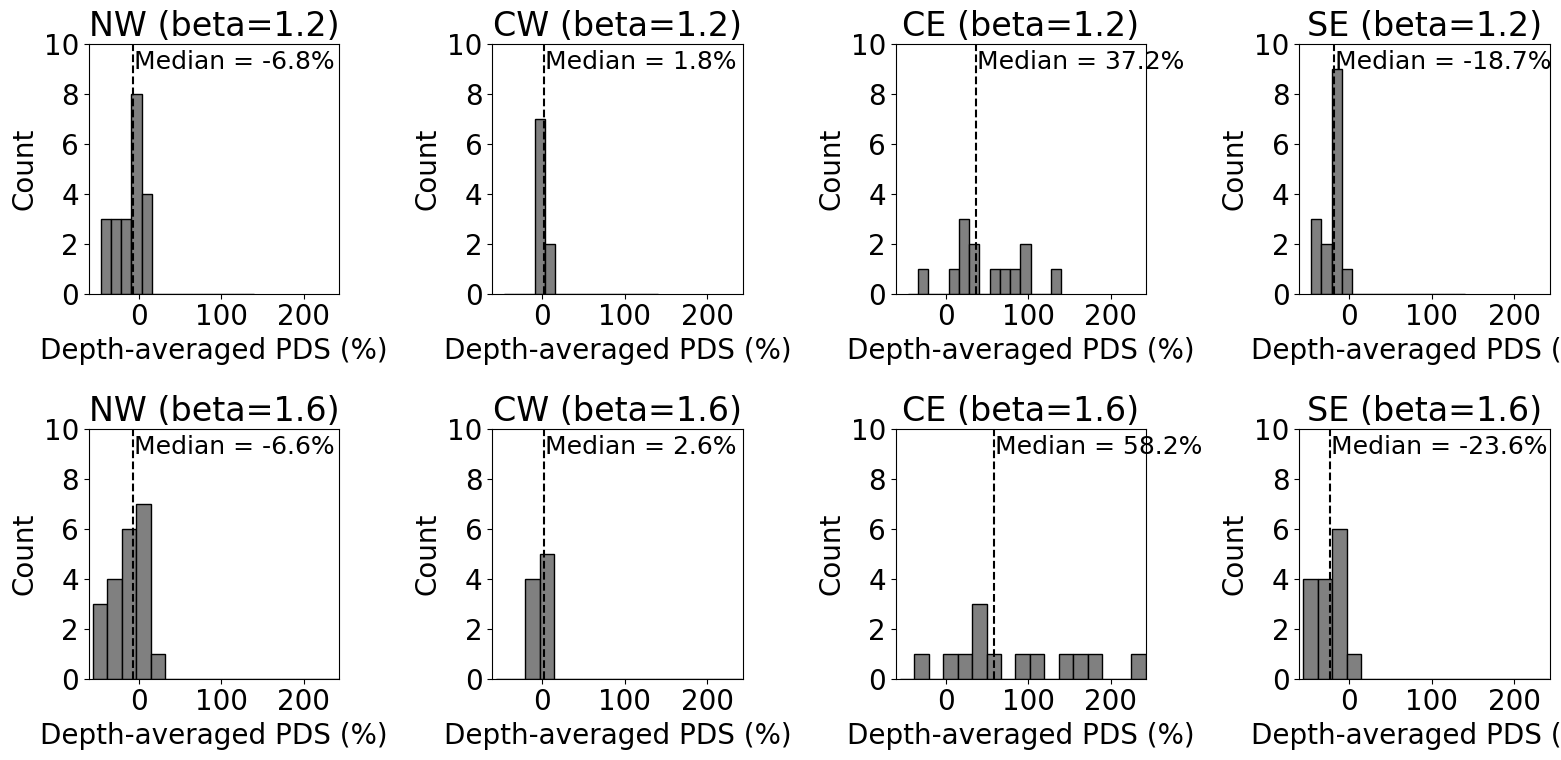

In [24]:
region_order = ["NW", "CW", "CE", "SE"]
n_regions = len(region_order)

pds_df["region"] = pd.Categorical(pds_df["region"], categories=region_order, ordered=True)
depth_avg_df["region"] = pd.Categorical(depth_avg_df["region"], categories=region_order, ordered=True)

regions = region_order

# set bin width using Freedman-Diaconis rule for each \beta group

# Separate the depth-averaged values by PDS type
all_1pt2 = depth_avg_df[depth_avg_df["beta_value"] == 1.2]["pds_percent"].dropna().values
all_1pt6 = depth_avg_df[depth_avg_df["beta_value"] == 1.6]["pds_percent"].dropna().values

# Freedman-Diaconis bin width for 1pt2
q75, q25 = np.percentile(all_1pt2, [75 ,25])
iqr = q75 - q25
n = len(all_1pt2)
bin_width_1pt2 = 2 * iqr / np.cbrt(n)
nbins_1pt2 = int(np.ceil((all_1pt2.max() - all_1pt2.min()) / bin_width_1pt2))

# Freedman-Diaconis bin width for 1pt6
q75, q25 = np.percentile(all_1pt6, [75 ,25])
iqr = q75 - q25
n = len(all_1pt6)
bin_width_1pt6 = 2 * iqr / np.cbrt(n)
nbins_1pt6 = int(np.ceil((all_1pt6.max() - all_1pt6.min()) / bin_width_1pt6))

# uniform bin edges across all histograms
bins_1pt2 = np.arange(all_1pt2.min(), all_1pt2.max() + bin_width_1pt2, bin_width_1pt2)
bins_1pt6 = np.arange(all_1pt6.min(), all_1pt6.max() + bin_width_1pt6, bin_width_1pt6)

xmin = min(all_1pt2.min(), all_1pt6.min()) - 5
xmax = max(all_1pt2.max(), all_1pt6.max()) + 5

fig, axes = plt.subplots(2, n_regions, figsize=(4*n_regions, 8), sharex=False, sharey=False)

for col, region in enumerate(regions):
    # Beta = 1.2 (PDS 1pt2) top row
    data_1pt2 = depth_avg_df[(depth_avg_df["region"]==region) & (depth_avg_df["beta_value"]==1.2)]["pds_percent"]
    axes[0, col].hist(data_1pt2.dropna(), bins=bins_1pt2, color="grey", edgecolor="k")
    axes[0, col].set_title(f"{region} (beta=1.2)")
    axes[0, col].set_xlabel("Depth-averaged PDS (%)")
    axes[0, col].set_ylabel("Count")
    axes[0, col].set_xlim(xmin, xmax)
    axes[0, col].set_ylim(0, 10)
    axes[0, col].set_xticks([0, 100, 200])
    axes[0, col].set_yticks(np.arange(0, 12, 2))

    # median lines
    median_regional_1pt2 = np.median(data_1pt2.dropna())
    axes[0, col].axvline(x=median_regional_1pt2, color='k', linestyle='--', label=f'Median = {median_regional_1pt2:.1f}%')
    
    #text label
    axes[0, col].text(
    median_regional_1pt2 + 1,
    axes[0, col].get_ylim()[1] * 0.9,
    f"Median = {median_regional_1pt2:.1f}%",
    fontsize=18,)
    
    # Beta = 1.6 (PDS 1pt6) bottom row
    data_1pt6 = depth_avg_df[(depth_avg_df["region"]==region) & (depth_avg_df["beta_value"]==1.6)]["pds_percent"]
    axes[1, col].hist(data_1pt6.dropna(), bins=bins_1pt6, color="grey", edgecolor="k")
    axes[1, col].set_title(f"{region} (beta=1.6)")
    axes[1, col].set_xlabel("Depth-averaged PDS (%)")
    axes[1, col].set_ylabel("Count")
    axes[1, col].set_xlim(xmin, xmax)
    axes[1, col].set_xticks([0, 100, 200])
    axes[1, col].set_ylim(0, 10)
    axes[1, col].set_yticks(np.arange(0, 12, 2))

    # median lines
    median_regional_1pt6 = np.median(data_1pt6.dropna())
    axes[1, col].axvline(x=median_regional_1pt6, color='k', linestyle='--', label=f'Median = {median_regional_1pt6:.1f}%')
    
    #text label
    axes[1, col].text(
    median_regional_1pt6 + 1,
    axes[1, col].get_ylim()[1] * 0.9,
    f"Median = {median_regional_1pt6:.1f}%",
    fontsize=18,)
    


plt.tight_layout()
plt.show()
plt.close()

## Single histogram of all profiles, separate for PDS values where beta = 1.2 (1pt2) and beta = 1.6 (1pt6)

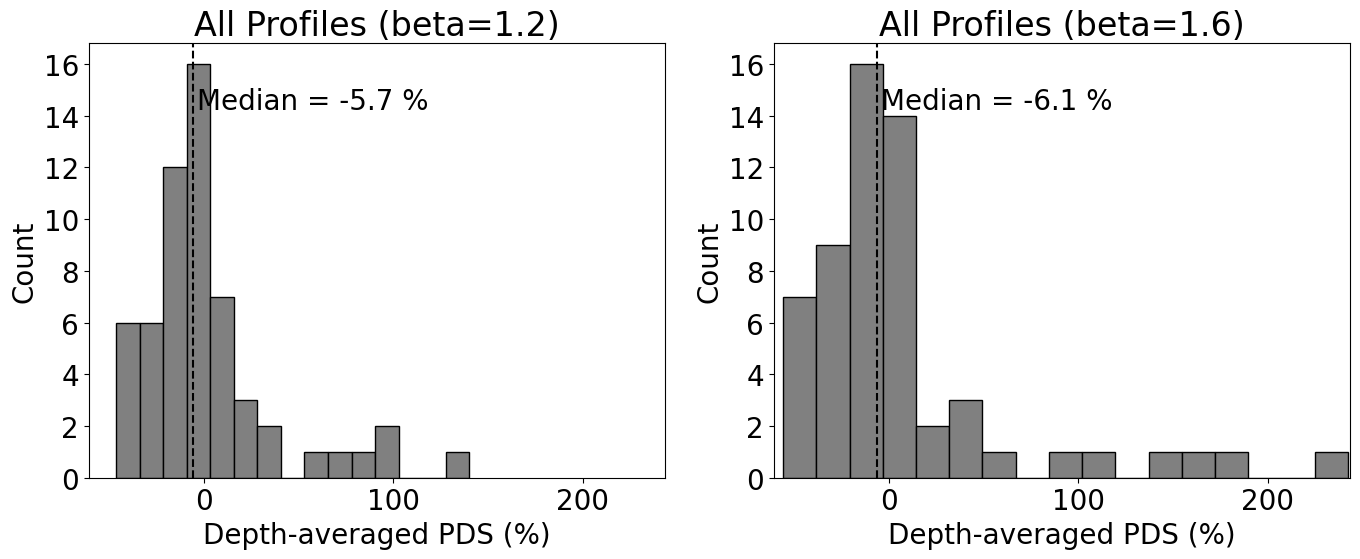

In [25]:

# Plot the two histograms side by side
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=False)

axes[0].hist(all_1pt2, bins=bins_1pt2, color="grey", edgecolor="k")
axes[0].set_title("All Profiles (beta=1.2)")
axes[0].set_xlabel("Depth-averaged PDS (%)")
axes[0].set_yticks(np.arange(0, 18, 2))
axes[0].set_ylabel("Count")

axes[1].hist(all_1pt6, bins=bins_1pt6, color="grey", edgecolor="k")
axes[1].set_title("All Profiles (beta=1.6)")
axes[1].set_xlabel("Depth-averaged PDS (%)")
axes[1].set_ylabel("Count")
axes[1].set_yticks(np.arange(0, 18, 2))

axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)

#median line
median_1pt2 = np.median(all_1pt2)
median_1pt6 = np.median(all_1pt6)
axes[0].axvline(x=median_1pt2, color='k', linestyle='--', label="Median")
axes[1].axvline(x=median_1pt6, color='k', linestyle='--', label="Median")

# label median values
axes[0].text(median_1pt2 + 2.0, 0.9 * axes[0].get_ylim()[1], f"Median = {median_1pt2:.1f} %", fontsize=20, va='top')
axes[1].text(median_1pt6 + 2.0, 0.9 *axes[1].get_ylim()[1], f"Median = {median_1pt6:.1f} %", fontsize=20, va='top')


plt.tight_layout()
plt.show()
plt.close()